In [1]:
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import json
import sys

sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/waxs_auto_processing/")
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/standard_functions/")
from waxs_auto_processing import *
from standard_functions import get_uid_list

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb

Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/



Tiled version 0.1.0a120


Re-imported pyCHX from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/
Re-imported chx_compress from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py

environment dependent settings and patches:
using "%matplotlib inline" for plotting


/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


### scans to be batch processed

In [16]:
scans = np.arange(150453,150460).tolist()
scans = np.arange(149580,150446).tolist() # this is the whole June beamtime!
scans = np.arange(150190,150446).tolist() # pick up where jupyter crashed...

scans = [157694] # start of homopolymer MI35, 100C printbed 10mm/s
scans = [157697] #
scans = [157818] # this one has been fixed by Dan -> this one worked, disabled pattern fitting to save time

scans = [157706,157718,157771,157766,157754,157783,157795,157801,157818]
scans =  [157830,  #100C bed, 10mm/s and 25mm/s in-situ
        157709,157721,157775,157769,157757,157786,157798,157804,157822,157834,  #100C bed, 10mm/s and 25mm/s first post series
        157710,157722,157776,157770,157758,157787,157799,157805,157823,157835]  #100C bed, 10mm/s and 25mm/s first post series
scans = [157758,157763]
scans = [157825,157828,157829]
user = 'lwiegart'
cycle = '2024_3'

##############################################################################################################
if user: user_=user
else: user_=None
if cycle: cycle_=cycle
else: cycle_=None
[s,uids]=get_uid_list(scans,user=user_,cycle=cycle_,fail_nonexisting=False)

### information needed for WAXS data processing

In [17]:
analyst = 'lwiegart'
calibration_uid = 157615 # WAXS detector position optimized for polypropylene sample (scan_id is likely to work, but provide uid if you can)
insert_dict={'template_name':'Pilatus800k_WAXS_analysis','analyst':analyst,'plotting':False,'pattern_fit':False} # need the template name, IF 'analyst' is missing, we assume it's the same as 'user'

### check whether uids in list can be processed
use remove_uids=True to remove uids that cannot be processed from the list

In [18]:
uids = check_waxs_processing_possible(uids,remove_uids=True,verbose=True)

scan_id: 157825 / uid: a9ae6e9f-4507-48a6-9050-e3799443d2c8 ->  processing should be possible!  
scan_id: 157828 / uid: 5e4d2fc0-6071-4d67-9d8f-b0590f36900e ->  processing should be possible!  
scan_id: 157829 / uid: 57e3b48b-cbca-484b-964e-8afc6444291a ->  processing should be possible!  


### process uids in list

Sun Oct 27 15:53:41 2024: start processing of scan_id: 157828 / uid: 5e4d2fc0-6071-4d67-9d8f-b0590f36900e    dataset 2 of 3


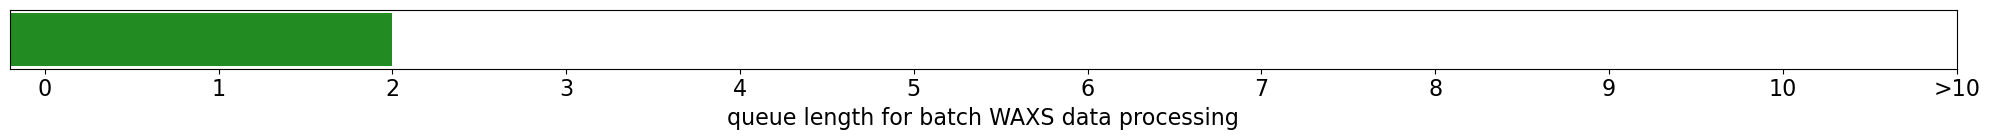

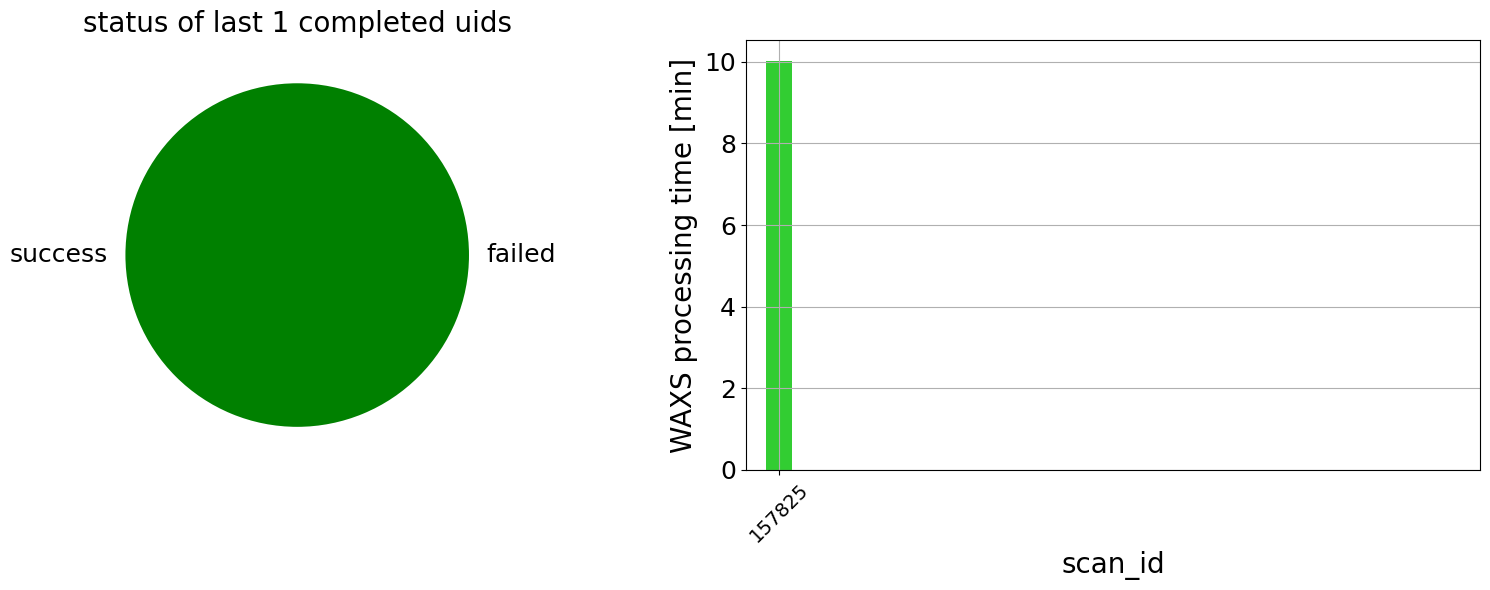

Passed unknown parameter: analyst
Passed unknown parameter: user
Passed unknown parameter: cycle
Passed unknown parameter: scan_list
Passed unknown parameter: calibration
Passed unknown parameter: plotting
Passed unknown parameter: pattern_fit


couldn't find image shape...skip!


Executing:   0%|          | 0/58 [00:00<?, ?cell/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


KeyboardInterrupt: 

In [19]:
stat_dict={}
for uu,uid in enumerate(uids):
    h=db[uid]
    display(clear=True,wait =True)
    print('%s: start processing of scan_id: %s / uid: %s    dataset %s of %s'%(time.ctime(time.time()),h.start['scan_id'],uid,uu+1,len(uids)))
    stat_dict[uid]={'start':time.time(),'stop':False,'status':False}
    show_batch_queue_stats(stat_dict,uids)
    try:
        chx_waxs_analysis(uid, _base_path_, calibration_uid, insert_dict=insert_dict, verbose=True)
        stat_dict[uid]['stop']=time.time();stat_dict[uid]['status']='success'
    except:
        stat_dict[uid]['stop']=time.time();stat_dict[uid]['status']='failed'
display(clear=True,wait =True)
print('%s: batch processing completed!'%(time.ctime(time.time())))
show_batch_queue_stats(stat_dict,uids)